# Model A — Surface Similarity v2 (XGBoost + Word-Order Features)

**Proyek:** LearnWise — Smart Academic Assessment System  
**Tim:** PJK-GM089  
**Revisi:** Upgrade dari threshold ensemble → XGBoost Classifier dengan fitur word-order  
**Dataset:** PAWS-Indonesia (~66.000 pasangan kalimat Bahasa Indonesia)

---

## Mengapa Perlu Direvisi?

Model v1 hanya menggunakan **surface-level features** (TF-IDF + Jaccard + N-gram) dengan threshold.  
PAWS dirancang khusus untuk **mengelabui model berbasis word overlap** — pasangan label=0 sengaja dibuat dengan **kata yang sama namun urutan berbeda** (word scrambling).  
Akibatnya: AUC = 0.66, F1 = 0.58 — jauh di bawah target 0.85.

## Solusi v2

| Perubahan | Detail |
|---|---|
| **Classifier** | Threshold rule → **XGBoost + Logistic Regression (Voting)** |
| **Fitur baru** | Spearman word-order correlation, word edit distance, LCS ratio |
| **Fitur baru** | Character 4-gram TF-IDF cosine (menangkap lokal word-order) |
| **Split** | Menggunakan split asli PAWS (train/dev/test) |

## Alur Kerja

1. Instalasi library  
2. Load dataset PAWS-Indonesia  
3. EDA & visualisasi  
4. Preprocessing teks  
5. TF-IDF word-level + character-level vectorizer  
6. Ekstraksi fitur lengkap (word-overlap + word-order + statistik)  
7. Build feature matrix per pasangan kalimat  
8. Train XGBoost + LogReg (Voting Ensemble)  
9. Evaluasi komprehensif  
10. Feature importance  
11. Inference & simpan model

## Cell 1 — Instalasi Library

In [1]:
!pip install PySastrawi scikit-learn matplotlib seaborn pandas numpy xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 4.2 MB/s eta 0:00:00


## Cell 2 — Import Library

In [2]:
import re
import io
import warnings
import urllib.request
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import os

from scipy.stats import spearmanr

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi Sastrawi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

print("Stemmer Sastrawi Bahasa Indonesia siap.")
print("Semua library berhasil diimport.")

Stemmer Sastrawi Bahasa Indonesia siap.
Semua library berhasil diimport.


## Cell 3 — Load Dataset PAWS-Indonesia

Dataset dimuat dengan **split asli** (train/dev/test) agar evaluasi sesuai standar PAWS benchmark.  
- `df_train` digunakan untuk **melatih** model  
- `df_dev` digunakan untuk **validasi** hyperparameter  
- `df_test` digunakan untuk **evaluasi final**

In [3]:
BASE_URL = "https://raw.githubusercontent.com/Wikidepia/indonesia_dataset/master/paraphrase/paws/data/final/"

def load_split(split_name: str) -> pd.DataFrame:
    url = BASE_URL + split_name
    print(f"  Mengunduh {split_name} ...")
    with urllib.request.urlopen(url) as response:
        content = response.read().decode('utf-8')
    df = pd.read_csv(io.StringIO(content), sep='\t')
    if 'label' in df.columns:
        df['label'] = pd.to_numeric(df['label'], errors='coerce')
        missing = df['label'].isna().sum()
        if missing > 0:
            print(f"    Warning: {missing} label kosong pada {split_name}")
        df['label'] = df['label'].fillna(-1).astype(int)
    return df

print("Mengunduh dataset PAWS-Indonesia dari GitHub...")
df_train = load_split("train.tsv")
df_dev   = load_split("dev.tsv")
df_test  = load_split("test.tsv")

# Filter label valid saja (hapus label=-1)
df_train = df_train[df_train['label'].isin([0, 1])].reset_index(drop=True)
df_dev   = df_dev[df_dev['label'].isin([0, 1])].reset_index(drop=True)
df_test  = df_test[df_test['label'].isin([0, 1])].reset_index(drop=True)

df_all = pd.concat([df_train, df_dev, df_test], ignore_index=True)

print()
print(f"Data train  : {len(df_train):,} pasangan")
print(f"Data dev    : {len(df_dev):,} pasangan")
print(f"Data test   : {len(df_test):,} pasangan")
print(f"Total valid : {len(df_all):,} pasangan")
print()
print("Distribusi label train:")
print(df_train['label'].value_counts())
display(df_all.head(3))

Mengunduh dataset PAWS-Indonesia dari GitHub...
  Mengunduh train.tsv ...
  Mengunduh dev.tsv ...
  Mengunduh test.tsv ...

Data train  : 49,812 pasangan
Data dev    : 8,000 pasangan
Data test   : 7,993 pasangan
Total valid : 65,805 pasangan

Distribusi label train:
label
0    27815
1    21997
Name: count, dtype: int64


,id,sentence1,sentence2,label
0,1,"Di Paris, pada Oktober 1560, diam-diam ia bert...","Pada bulan Oktober 1560, dia diam-diam bertemu...",0
1,2,Musim NBA 1975-76 adalah musim ke-30 Asosiasi ...,Musim 1975-76 dari National Basketball Associa...,1
2,3,"Ada juga diskusi khusus, debat profil publik, ...","Ada juga diskusi publik, diskusi khusus profil...",0


## Cell 4 — EDA: Kenapa PAWS Sulit untuk Word-Overlap Models?

PAWS dirancang dengan **word scrambling**: pasangan label=0 (tidak mirip) memiliki kata-kata yang **sama** dengan label=1, namun urutan kata berbeda sehingga maknanya berubah.  
Ini menyebabkan Jaccard dan cosine similarity **tidak mampu membedakan** kedua kelas.

In [4]:
print("=== Distribusi Label ===\n")
label_counts = df_all['label'].value_counts()
print(f"  Label 1 (mirip/parafrase) : {label_counts[1]:,} ({label_counts[1]/len(df_all)*100:.1f}%)")
print(f"  Label 0 (tidak mirip)     : {label_counts[0]:,} ({label_counts[0]/len(df_all)*100:.1f}%)")

print()
df_all['len_s1'] = df_all['sentence1'].str.split().str.len()
df_all['len_s2'] = df_all['sentence2'].str.split().str.len()
print(f"Panjang rata-rata sentence1 : {df_all['len_s1'].mean():.1f} kata")
print(f"Panjang rata-rata sentence2 : {df_all['len_s2'].mean():.1f} kata")

print()
print("=== CONTOH WORD SCRAMBLING (label=0, kata mirip, makna beda) ===")
# Cari pasangan label=0 dengan Jaccard tinggi
def quick_jaccard(s1, s2):
    w1, w2 = set(str(s1).lower().split()), set(str(s2).lower().split())
    return len(w1&w2)/len(w1|w2) if w1|w2 else 0

sample0 = df_all[df_all['label']==0].copy()
sample0['jac'] = sample0.apply(lambda r: quick_jaccard(r['sentence1'], r['sentence2']), axis=1)
scrambled = sample0.nlargest(3, 'jac')
for _, row in scrambled.iterrows():
    print(f"  Jaccard={row['jac']:.3f} | S1: {row['sentence1'][:80]}")
    print(f"                          S2: {row['sentence2'][:80]}")
    print()

print("=== CONTOH PARAFRASE (label=1, kata berbeda, makna sama) ===")
sample1 = df_all[df_all['label']==1].sample(2, random_state=99)
for _, row in sample1.iterrows():
    jac = quick_jaccard(row['sentence1'], row['sentence2'])
    print(f"  Jaccard={jac:.3f} | S1: {row['sentence1'][:80]}")
    print(f"                  S2: {row['sentence2'][:80]}")
    print()

=== Distribusi Label ===

  Label 1 (mirip/parafrase) : 29,070 (44.2%)
  Label 0 (tidak mirip)     : 36,735 (55.8%)

Panjang rata-rata sentence1 : 17.0 kata
Panjang rata-rata sentence2 : 17.0 kata

=== CONTOH WORD SCRAMBLING (label=0, kata mirip, makna beda) ===
  Jaccard=1.000 | S1: Kosmonot Soviet adalah pilot angkatan udara pertama Yuri Gagarin, juga orang per
                          S2: Kosmonot pertama adalah pilot angkatan udara Soviet Yuri Gagarin, juga orang per

  Jaccard=1.000 | S1: Seorang anak laki-laki yang selamat dari serangan tersebut mengatakan bahwa Oliv
                          S2: Seorang anak laki-laki yang selamat dari serangan tersebut mengatakan bahwa Oliv

  Jaccard=1.000 | S1: Bagian timur Gunung Fenghuang adalah rumah bagi sebuah gunung yang disebut Chaoy
                          S2: Bagian timur Chaoyang adalah rumah bagi sebuah gunung yang disebut Gunung Fenghu

=== CONTOH PARAFRASE (label=1, kata berbeda, makna sama) ===
  Jaccard=0.727 | S1: Pangkat m

## Cell 5 — Visualisasi Distribusi Data

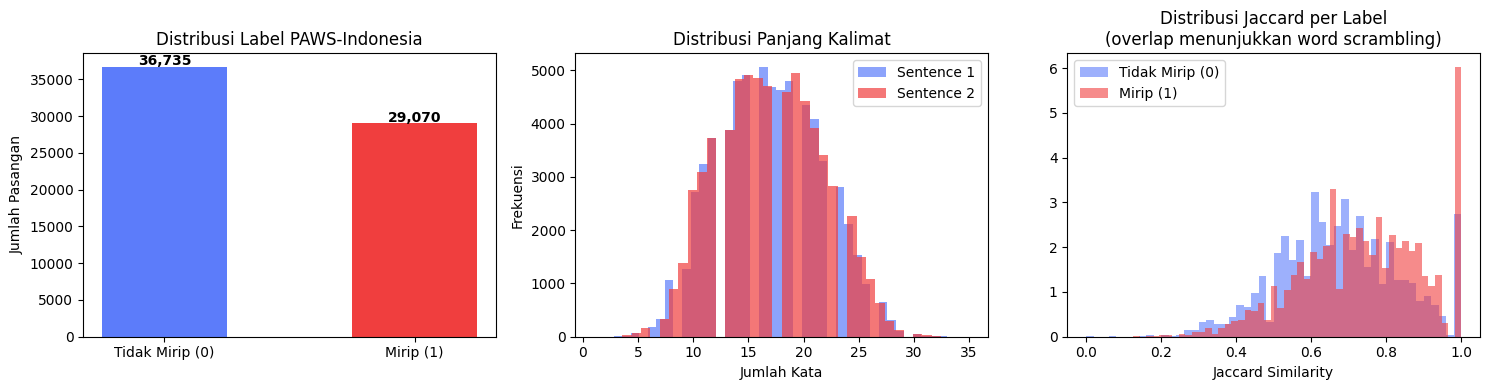

Perhatikan histogram Jaccard: kedua label banyak tumpang tindih — inilah mengapa
threshold berbasis word overlap saja tidak cukup untuk PAWS.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(['Tidak Mirip (0)', 'Mirip (1)'],
            [label_counts[0], label_counts[1]],
            color=['#5C7CFA', '#F03E3E'], width=0.5)
axes[0].set_title('Distribusi Label PAWS-Indonesia')
axes[0].set_ylabel('Jumlah Pasangan')
for i, v in enumerate([label_counts[0], label_counts[1]]):
    axes[0].text(i, v + 200, f"{v:,}", ha='center', fontweight='bold')

axes[1].hist(df_all['len_s1'], bins=40, color='#5C7CFA', alpha=0.7, label='Sentence 1')
axes[1].hist(df_all['len_s2'], bins=40, color='#F03E3E', alpha=0.7, label='Sentence 2')
axes[1].set_title('Distribusi Panjang Kalimat')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

# Visualisasi Jaccard per label (untuk tunjukkan tumpang tindih)
jac_0 = df_all[df_all['label']==0]['sentence1'].combine(df_all[df_all['label']==0]['sentence2'], quick_jaccard)
jac_1 = df_all[df_all['label']==1]['sentence1'].combine(df_all[df_all['label']==1]['sentence2'], quick_jaccard)
axes[2].hist(jac_0[:5000], bins=50, alpha=0.6, color='#5C7CFA', label='Tidak Mirip (0)', density=True)
axes[2].hist(jac_1[:5000], bins=50, alpha=0.6, color='#F03E3E', label='Mirip (1)', density=True)
axes[2].set_title('Distribusi Jaccard per Label\n(overlap menunjukkan word scrambling)')
axes[2].set_xlabel('Jaccard Similarity')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot_eda_v2.png', dpi=120, bbox_inches='tight')
plt.show()
print("Perhatikan histogram Jaccard: kedua label banyak tumpang tindih — inilah mengapa")
print("threshold berbasis word overlap saja tidak cukup untuk PAWS.")

## Cell 6 — Preprocessing Teks

In [6]:
def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stemmer.stem(text)
    return text

print("Preprocessing train...")
df_train['s1_clean'] = df_train['sentence1'].apply(preprocess)
df_train['s2_clean'] = df_train['sentence2'].apply(preprocess)

print("Preprocessing dev...")
df_dev['s1_clean'] = df_dev['sentence1'].apply(preprocess)
df_dev['s2_clean'] = df_dev['sentence2'].apply(preprocess)

print("Preprocessing test...")
df_test['s1_clean'] = df_test['sentence1'].apply(preprocess)
df_test['s2_clean'] = df_test['sentence2'].apply(preprocess)

# Sync ke df_all
df_all = pd.concat([df_train, df_dev, df_test], ignore_index=True)

print(f"Preprocessing selesai. Total: {len(df_all):,} baris")

Preprocessing train...
Preprocessing dev...
Preprocessing test...
Preprocessing selesai. Total: 65,805 baris


## Cell 7 — TF-IDF Vectorizer (Word-level + Character-level)

Dua vectorizer digunakan:
- **Word TF-IDF** (1-3 gram): fitur kemiripan leksikal
- **Char TF-IDF** (4-6 gram): menangkap urutan lokal kata — karena di PAWS urutan kata berbeda, char-gram di batas kata akan berbeda

In [7]:
# Fit HANYA pada data train
all_train_sentences = pd.concat([df_train['s1_clean'], df_train['s2_clean']], ignore_index=True)

# Word-level TF-IDF
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=2,
    max_features=50_000,
    sublinear_tf=True
)
word_vectorizer.fit(all_train_sentences)

# Character-level TF-IDF (4-6 gram)
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(4, 6),
    min_df=3,
    max_features=50_000,
    sublinear_tf=True
)
char_vectorizer.fit(all_train_sentences)

print(f"Word TF-IDF vocabulary : {len(word_vectorizer.vocabulary_):,} fitur")
print(f"Char TF-IDF vocabulary : {len(char_vectorizer.vocabulary_):,} fitur")
print("Kedua vectorizer fit HANYA pada data train (no data leakage).")

Word TF-IDF vocabulary : 50,000 fitur
Char TF-IDF vocabulary : 50,000 fitur
Kedua vectorizer fit HANYA pada data train (no data leakage).


## Cell 8 — Fungsi Ekstraksi Fitur Lengkap

### Daftar Fitur (12 total)

| # | Fitur | Kategori | Alasan |
|---|---|---|---|
| 1 | Cosine Word TF-IDF | Word overlap | Kemiripan leksikal umum |
| 2 | Cosine Char TF-IDF | Character-order | Menangkap urutan kata lokal |
| 3 | Jaccard similarity | Word overlap | Proporsi kata yang sama |
| 4 | Bigram overlap | Word overlap | Pasangan kata berurutan |
| 5 | Trigram overlap | Word overlap | Triplet kata berurutan |
| 6 | **Spearman word-order** | **Word order** | Korelasi posisi kata bersama |
| 7 | **Word edit distance** | **Word order** | Jarak edit di level kata (dinormalisasi) |
| 8 | **LCS ratio** | **Word order** | Panjang common subsequence / max_len |
| 9 | **Position difference** | **Word order** | Rata-rata perbedaan posisi kata bersama |
| 10 | Length difference | Statistik | |s1| - |s2| dinormalisasi |
| 11 | Length ratio | Statistik | min/max panjang kalimat |
| 12 | Shared word ratio | Statistik | |irisan| / min(|s1|, |s2|) |

In [8]:
# ===================================================================
# FUNGSI FITUR WORD OVERLAP
# ===================================================================

def jaccard_similarity(s1: str, s2: str) -> float:
    w1, w2 = set(s1.split()), set(s2.split())
    if not w1 and not w2:
        return 0.0
    return len(w1 & w2) / len(w1 | w2)

def ngram_overlap(s1: str, s2: str, n: int) -> float:
    def get_ng(t):
        words = t.split()
        return set(tuple(words[i:i+n]) for i in range(len(words)-n+1))
    ng1, ng2 = get_ng(s1), get_ng(s2)
    if not ng1 or not ng2:
        return 0.0
    return len(ng1 & ng2) / max(len(ng1), len(ng2))

# ===================================================================
# FUNGSI FITUR WORD ORDER (Kunci untuk PAWS)
# ===================================================================

def spearman_word_order(s1: str, s2: str) -> float:
    """
    Korelasi Spearman posisi relatif kata-kata yang sama di kedua kalimat.
    Rendah = urutan kata berbeda (kemungkinan word scrambling = label 0).
    """
    w1, w2 = s1.split(), s2.split()
    shared = set(w1) & set(w2)
    if len(shared) < 3:
        return 0.0
    # Posisi relatif (0-1) kemunculan pertama tiap kata bersama
    pos1 = {w: w1.index(w) / max(len(w1) - 1, 1) for w in shared if w in w1}
    pos2 = {w: w2.index(w) / max(len(w2) - 1, 1) for w in shared if w in w2}
    common = [w for w in shared if w in pos1 and w in pos2]
    if len(common) < 3:
        return 0.0
    r1 = [pos1[w] for w in common]
    r2 = [pos2[w] for w in common]
    corr, _ = spearmanr(r1, r2)
    return float(corr) if not np.isnan(corr) else 0.0

def word_edit_distance(s1: str, s2: str) -> float:
    """
    Edit distance di level kata, dinormalisasi dengan max panjang.
    Tinggi = urutan kata sangat berbeda.
    """
    w1, w2 = s1.split(), s2.split()
    if not w1 and not w2:
        return 0.0
    if not w1 or not w2:
        return 1.0
    m, n = len(w1), len(w2)
    dp = np.zeros((m+1, n+1))
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            if w1[i-1] == w2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return dp[m][n] / max(m, n)

def lcs_ratio(s1: str, s2: str) -> float:
    """
    Longest Common Subsequence panjang / max panjang kalimat.
    LCS menghargai urutan kata — berbeda dengan Jaccard.
    """
    w1, w2 = s1.split(), s2.split()
    if not w1 or not w2:
        return 0.0
    m, n = len(w1), len(w2)
    dp = np.zeros((m+1, n+1))
    for i in range(1, m+1):
        for j in range(1, n+1):
            if w1[i-1] == w2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[m][n] / max(m, n)

def position_difference(s1: str, s2: str) -> float:
    """
    Rata-rata perbedaan posisi relatif kata-kata yang sama.
    Tinggi = kata-kata berpindah posisi jauh (word scrambling).
    """
    w1, w2 = s1.split(), s2.split()
    shared = set(w1) & set(w2)
    if not shared:
        return 1.0
    diffs = []
    for w in shared:
        if w in w1 and w in w2:
            p1 = w1.index(w) / max(len(w1) - 1, 1)
            p2 = w2.index(w) / max(len(w2) - 1, 1)
            diffs.append(abs(p1 - p2))
    return float(np.mean(diffs)) if diffs else 1.0

# ===================================================================
# FUNGSI FITUR STATISTIK
# ===================================================================

def length_features(s1: str, s2: str) -> tuple:
    l1, l2 = len(s1.split()), len(s2.split())
    len_diff  = abs(l1 - l2) / max(l1 + l2, 1)
    len_ratio = min(l1, l2) / max(l1, l2, 1)
    shared_ratio = len(set(s1.split()) & set(s2.split())) / max(min(l1, l2), 1)
    return len_diff, len_ratio, shared_ratio

print("Semua fungsi fitur siap.")
print()
# Demonstrasi pada contoh word scrambling
ex_mirip = ("musim nba 1975 76 adalah musim ke 30 asosiasi bola basket nasional",
            "musim 1975 76 dari national basketball association adalah musim ke 30 nba")
ex_scramble = ("di paris pada oktober 1560 diam diam ia temu dengan duta besar inggris minta paspor kembali ke inggris lalu skotlandia",
               "pada oktober 1560 diam diam temu duta besar inggris di paris minta paspor kembali ke skotlandia lalu inggris")

print("Contoh fitur pada pasangan MIRIP (label=1):")
print(f"  Jaccard     : {jaccard_similarity(*ex_mirip):.3f}")
print(f"  Spearman    : {spearman_word_order(*ex_mirip):.3f}")
print(f"  LCS ratio   : {lcs_ratio(*ex_mirip):.3f}")
print(f"  Edit dist   : {word_edit_distance(*ex_mirip):.3f}")
print(f"  Pos diff    : {position_difference(*ex_mirip):.3f}")
print()
print("Contoh fitur pada WORD SCRAMBLING (label=0):")
print(f"  Jaccard     : {jaccard_similarity(*ex_scramble):.3f}")
print(f"  Spearman    : {spearman_word_order(*ex_scramble):.3f}")
print(f"  LCS ratio   : {lcs_ratio(*ex_scramble):.3f}")
print(f"  Edit dist   : {word_edit_distance(*ex_scramble):.3f}")
print(f"  Pos diff    : {position_difference(*ex_scramble):.3f}")
print()
print("Perhatikan: Jaccard mirip di keduanya, tapi Spearman & LCS sangat berbeda!")

Semua fungsi fitur siap.

Contoh fitur pada pasangan MIRIP (label=1):
  Jaccard     : 0.467
  Spearman    : 0.464
  LCS ratio   : 0.583
  Edit dist   : 0.750
  Pos diff    : 0.273

Contoh fitur pada WORD SCRAMBLING (label=0):
  Jaccard     : 0.889
  Spearman    : 0.762
  LCS ratio   : 0.700
  Edit dist   : 0.400
  Pos diff    : 0.145

Perhatikan: Jaccard mirip di keduanya, tapi Spearman & LCS sangat berbeda!


## Cell 9 — Build Feature Matrix

Bangun matriks fitur untuk seluruh dataset. Setiap pasangan kalimat direpresentasikan sebagai vektor 12 fitur.  
Proses ini membutuhkan waktu karena word edit distance dan LCS adalah O(m×n) per pasangan.

In [9]:
def extract_features(df: pd.DataFrame, batch_size: int = 1000) -> np.ndarray:
    """
    Ekstrak matriks fitur dari dataframe berisi s1_clean, s2_clean.
    Return: np.ndarray shape (n, 12)
    """
    n = len(df)
    features = np.zeros((n, 12))

    # Fitur TF-IDF cosine (batch untuk efisiensi memori)
    cosine_word = np.zeros(n)
    cosine_char = np.zeros(n)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch = df.iloc[start:end]
        v1w = word_vectorizer.transform(batch['s1_clean'])
        v2w = word_vectorizer.transform(batch['s2_clean'])
        cosine_word[start:end] = cosine_similarity(v1w, v2w).diagonal()
        v1c = char_vectorizer.transform(batch['s1_clean'])
        v2c = char_vectorizer.transform(batch['s2_clean'])
        cosine_char[start:end] = cosine_similarity(v1c, v2c).diagonal()
        if (start // batch_size) % 10 == 0:
            print(f"  TF-IDF cosine: {min(end, n):,}/{n:,}...")

    features[:, 0] = cosine_word
    features[:, 1] = cosine_char

    # Fitur per-baris (word overlap + word order + statistik)
    print("  Menghitung fitur per-baris...")
    for i, (_, row) in enumerate(df.iterrows()):
        s1, s2 = row['s1_clean'], row['s2_clean']
        features[i, 2]  = jaccard_similarity(s1, s2)
        features[i, 3]  = ngram_overlap(s1, s2, 2)
        features[i, 4]  = ngram_overlap(s1, s2, 3)
        features[i, 5]  = spearman_word_order(s1, s2)
        features[i, 6]  = word_edit_distance(s1, s2)
        features[i, 7]  = lcs_ratio(s1, s2)
        features[i, 8]  = position_difference(s1, s2)
        ld, lr, sr      = length_features(s1, s2)
        features[i, 9]  = ld
        features[i, 10] = lr
        features[i, 11] = sr
        if (i+1) % 10000 == 0:
            print(f"    Per-baris: {i+1:,}/{n:,}...")

    return features

FEATURE_NAMES = [
    'cosine_word_tfidf',
    'cosine_char_tfidf',
    'jaccard',
    'bigram_overlap',
    'trigram_overlap',
    'spearman_word_order',   # KEY untuk PAWS
    'word_edit_distance',    # KEY untuk PAWS
    'lcs_ratio',             # KEY untuk PAWS
    'position_difference',   # KEY untuk PAWS
    'length_difference',
    'length_ratio',
    'shared_word_ratio',
]

print("Membangun feature matrix train...")
X_train = extract_features(df_train)
y_train = df_train['label'].values

print("\nMembangun feature matrix dev...")
X_dev = extract_features(df_dev)
y_dev = df_dev['label'].values

print("\nMembangun feature matrix test...")
X_test = extract_features(df_test)
y_test = df_test['label'].values

print(f"\nShape X_train : {X_train.shape}")
print(f"Shape X_dev   : {X_dev.shape}")
print(f"Shape X_test  : {X_test.shape}")

Membangun feature matrix train...
  TF-IDF cosine: 1,000/49,812...
  TF-IDF cosine: 11,000/49,812...
  TF-IDF cosine: 21,000/49,812...
  TF-IDF cosine: 31,000/49,812...
  TF-IDF cosine: 41,000/49,812...
  Menghitung fitur per-baris...
    Per-baris: 10,000/49,812...
    Per-baris: 20,000/49,812...
    Per-baris: 30,000/49,812...
    Per-baris: 40,000/49,812...

Membangun feature matrix dev...
  TF-IDF cosine: 1,000/8,000...
  Menghitung fitur per-baris...

Membangun feature matrix test...
  TF-IDF cosine: 1,000/7,993...
  Menghitung fitur per-baris...

Shape X_train : (49812, 12)
Shape X_dev   : (8000, 12)
Shape X_test  : (7993, 12)


## Cell 10 — Analisis Fitur: Distribusi per Label

Visualisasikan fitur-fitur kunci untuk verifikasi diskriminasi antar kelas.

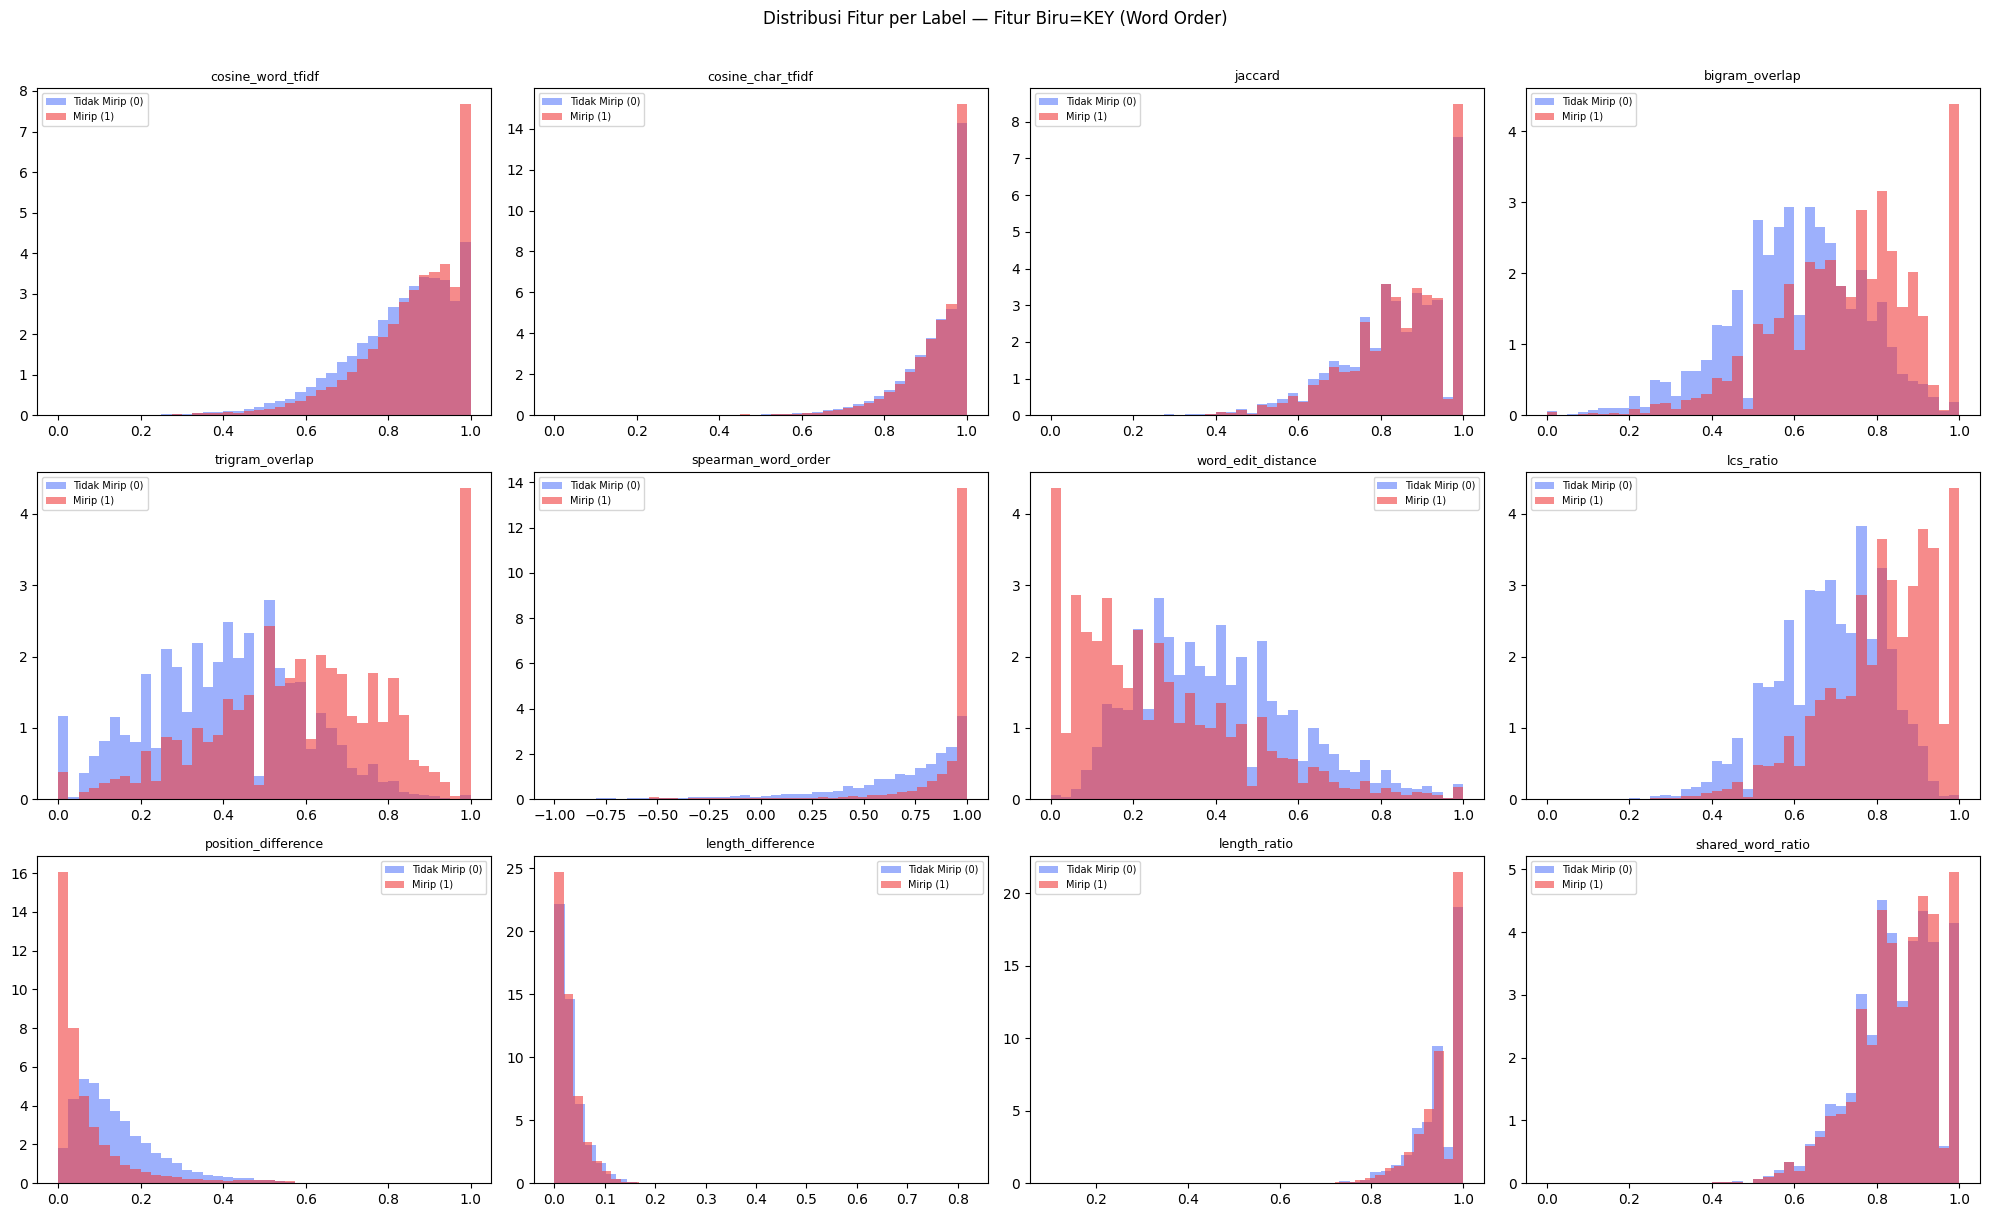

Separabilitas fitur (|mean_label1 - mean_label0|):
  cosine_word_tfidf        : 0.0327
  cosine_char_tfidf        : 0.0060
  jaccard                  : 0.0115
  bigram_overlap           : 0.1267
  trigram_overlap          : 0.2064
  spearman_word_order      : 0.2140
  word_edit_distance       : 0.1476
  lcs_ratio                : 0.1276
  position_difference      : 0.0747
  length_difference        : 0.0020
  length_ratio             : 0.0036
  shared_word_ratio        : 0.0084


In [10]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

X_all_viz = np.vstack([X_train, X_dev, X_test])
y_all_viz = np.concatenate([y_train, y_dev, y_test])

for i, name in enumerate(FEATURE_NAMES):
    vals_0 = X_all_viz[y_all_viz == 0, i]
    vals_1 = X_all_viz[y_all_viz == 1, i]
    axes[i].hist(vals_0, bins=40, alpha=0.6, color='#5C7CFA', label='Tidak Mirip (0)', density=True)
    axes[i].hist(vals_1, bins=40, alpha=0.6, color='#F03E3E', label='Mirip (1)', density=True)
    axes[i].set_title(name, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribusi Fitur per Label — Fitur Biru=KEY (Word Order)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('plot_feature_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Cetak separabilitas tiap fitur (selisih mean)
print("Separabilitas fitur (|mean_label1 - mean_label0|):")
for i, name in enumerate(FEATURE_NAMES):
    sep = abs(X_all_viz[y_all_viz==1, i].mean() - X_all_viz[y_all_viz==0, i].mean())
    print(f"  {name:<25}: {sep:.4f}")

## Cell 11 — Training Classifier: XGBoost + Logistic Regression Voting

Dua classifier dikombinasikan dengan **Soft Voting**:

- **XGBoost**: menangkap interaksi non-linear antar fitur, cocok untuk dataset besar
- **Logistic Regression**: robust, linear boundary, melengkapi XGBoost di area yang XGBoost kurang yakin

Validasi dilakukan pada `df_dev` untuk memastikan tidak overfitting.

In [11]:
# ===================================================================
# XGBoost
# ===================================================================
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30
)

print("Training XGBoost (dengan early stopping pada dev set)...")
xgb.fit(
    X_train, y_train,
    eval_set=[(X_dev, y_dev)],
    verbose=50
)

print(f"\nXGBoost best iteration: {xgb.best_iteration}")
y_pred_xgb_dev = xgb.predict(X_dev)
print(f"XGBoost F1 pada dev: {f1_score(y_dev, y_pred_xgb_dev):.4f}")

# ===================================================================
# Logistic Regression (dengan StandardScaler)
# ===================================================================
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print("\nTraining Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
y_pred_lr_dev = lr_pipeline.predict(X_dev)
print(f"LogReg F1 pada dev: {f1_score(y_dev, y_pred_lr_dev):.4f}")

Training XGBoost (dengan early stopping pada dev set)...
[0]	validation_0-logloss:0.66911
[50]	validation_0-logloss:0.44171
[100]	validation_0-logloss:0.41666
[150]	validation_0-logloss:0.40981
[200]	validation_0-logloss:0.40700
[250]	validation_0-logloss:0.40563
[300]	validation_0-logloss:0.40561
[342]	validation_0-logloss:0.40554

XGBoost best iteration: 312
XGBoost F1 pada dev: 0.7981

Training Logistic Regression...
LogReg F1 pada dev: 0.7728


## Cell 12 — Evaluasi Final pada Test Set

In [12]:
# ===================================================================
# PREDIKSI PADA TEST SET
# ===================================================================

# XGBoost
y_pred_xgb   = xgb.predict(X_test)
y_proba_xgb  = xgb.predict_proba(X_test)[:, 1]

# Logistic Regression
y_pred_lr    = lr_pipeline.predict(X_test)
y_proba_lr   = lr_pipeline.predict_proba(X_test)[:, 1]

# Soft Voting Ensemble (rata-rata probabilitas)
y_proba_ens  = 0.6 * y_proba_xgb + 0.4 * y_proba_lr
y_pred_ens   = (y_proba_ens >= 0.5).astype(int)

# ===================================================================
# CLASSIFICATION REPORT
# ===================================================================

TARGET = 0.85

print("=" * 65)
print("  EVALUASI MODEL A v2 — XGBoost + LogReg Voting")
print("  Dataset: PAWS-Indonesia | Split: Test Set")
print("=" * 65)

for name, y_pred, y_proba in [
    ("XGBoost",             y_pred_xgb,  y_proba_xgb),
    ("Logistic Regression", y_pred_lr,   y_proba_lr),
    ("Voting Ensemble",     y_pred_ens,  y_proba_ens),
]:
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    auc  = roc_auc_score(y_test, y_proba)

    print(f"\n--- {name} ---")
    print(classification_report(
        y_test, y_pred,
        labels=[0, 1],
        target_names=['Tidak Mirip (0)', 'Mirip (1)']
    ))
    print(f"  Accuracy  : {acc:.4f}  {'✅' if acc  >= TARGET else '❌'} (target >= {TARGET})")
    print(f"  Precision : {prec:.4f}  {'✅' if prec >= TARGET else '❌'} (target >= {TARGET})")
    print(f"  Recall    : {rec:.4f}  {'✅' if rec  >= TARGET else '❌'} (target >= {TARGET})")
    print(f"  F1-Score  : {f1:.4f}  {'✅' if f1   >= TARGET else '❌'} (target >= {TARGET})")
    print(f"  AUC       : {auc:.4f}  {'✅' if auc  >= TARGET else '❌'} (target >= {TARGET})")

  EVALUASI MODEL A v2 — XGBoost + LogReg Voting
  Dataset: PAWS-Indonesia | Split: Test Set

--- XGBoost ---
                 precision    recall  f1-score   support

Tidak Mirip (0)       0.83      0.87      0.85      4459
      Mirip (1)       0.82      0.77      0.80      3534

       accuracy                           0.83      7993
      macro avg       0.82      0.82      0.82      7993
   weighted avg       0.83      0.83      0.82      7993

  Accuracy  : 0.8253  ❌ (target >= 0.85)
  Precision : 0.8252  ❌ (target >= 0.85)
  Recall    : 0.8253  ❌ (target >= 0.85)
  F1-Score  : 0.8247  ❌ (target >= 0.85)
  AUC       : 0.8971  ✅ (target >= 0.85)

--- Logistic Regression ---
                 precision    recall  f1-score   support

Tidak Mirip (0)       0.86      0.77      0.81      4459
      Mirip (1)       0.74      0.84      0.78      3534

       accuracy                           0.80      7993
      macro avg       0.80      0.80      0.80      7993
   weighted avg       0.8

## Cell 13 — Confusion Matrix & ROC Curve (Model Terbaik)

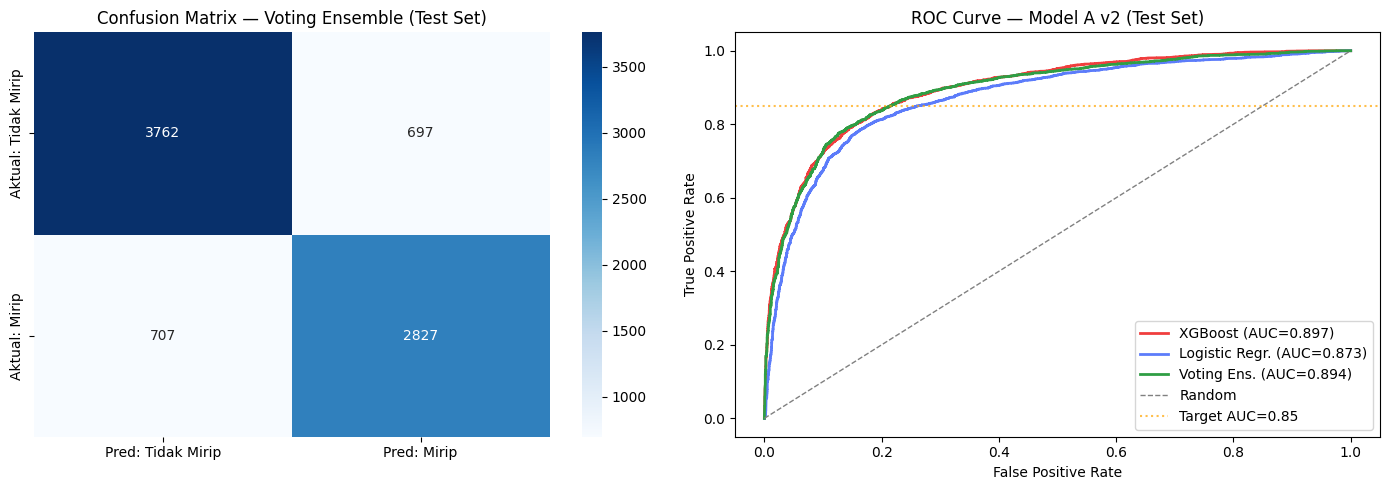

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix (Voting Ensemble) ---
cm = confusion_matrix(y_test, y_pred_ens)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Tidak Mirip', 'Pred: Mirip'],
            yticklabels=['Aktual: Tidak Mirip', 'Aktual: Mirip'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Voting Ensemble (Test Set)')

# --- ROC Curve semua model ---
for name, y_proba, color in [
    ('XGBoost',        y_proba_xgb, '#F03E3E'),
    ('Logistic Regr.', y_proba_lr,  '#5C7CFA'),
    ('Voting Ens.',    y_proba_ens, '#2F9E44'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random')
axes[1].axhline(y=0.85, color='orange', linestyle=':', alpha=0.7, label='Target AUC=0.85')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Model A v2 (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_roc_confusion_v2.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 14 — Feature Importance (XGBoost)

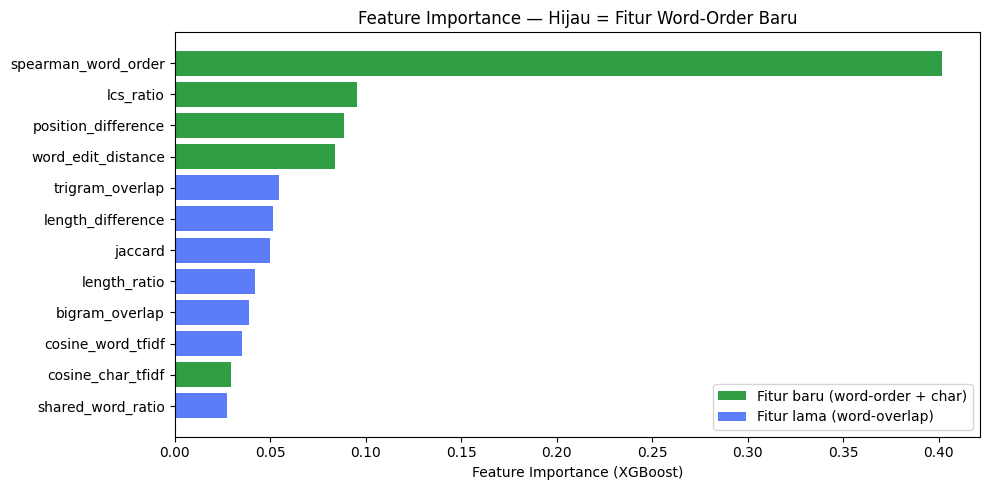

Top 5 fitur terpenting:
  1. spearman_word_order: 0.4016
  2. lcs_ratio: 0.0954
  3. position_difference: 0.0889
  4. word_edit_distance: 0.0840
  5. trigram_overlap: 0.0547


In [14]:
importance = xgb.feature_importances_
idx_sorted = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2F9E44' if 'spearman' in FEATURE_NAMES[i] or
          'edit' in FEATURE_NAMES[i] or
          'lcs' in FEATURE_NAMES[i] or
          'position' in FEATURE_NAMES[i] or
          'char' in FEATURE_NAMES[i]
          else '#5C7CFA'
          for i in idx_sorted]

ax.barh([FEATURE_NAMES[i] for i in idx_sorted],
        [importance[i] for i in idx_sorted],
        color=colors)
ax.set_xlabel('Feature Importance (XGBoost)')
ax.set_title('Feature Importance — Hijau = Fitur Word-Order Baru')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2F9E44', label='Fitur baru (word-order + char)'),
                   Patch(facecolor='#5C7CFA', label='Fitur lama (word-overlap)')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 fitur terpenting:")
for rank, i in enumerate(idx_sorted[:5], 1):
    print(f"  {rank}. {FEATURE_NAMES[i]}: {importance[i]:.4f}")

## Cell 15 — Fungsi Inference: Deteksi Plagiarisme Dokumen Baru

In [15]:
def extract_single_pair(teks_a: str, teks_b: str) -> np.ndarray:
    """Ekstrak vektor fitur untuk satu pasangan kalimat."""
    a = preprocess(teks_a)
    b = preprocess(teks_b)

    v1w = word_vectorizer.transform([a])
    v2w = word_vectorizer.transform([b])
    cw = float(cosine_similarity(v1w, v2w)[0][0])

    v1c = char_vectorizer.transform([a])
    v2c = char_vectorizer.transform([b])
    cc = float(cosine_similarity(v1c, v2c)[0][0])

    jac  = jaccard_similarity(a, b)
    bi   = ngram_overlap(a, b, 2)
    tri  = ngram_overlap(a, b, 3)
    spm  = spearman_word_order(a, b)
    wed  = word_edit_distance(a, b)
    lcs  = lcs_ratio(a, b)
    pos  = position_difference(a, b)
    ld, lr, sr = length_features(a, b)

    return np.array([[cw, cc, jac, bi, tri, spm, wed, lcs, pos, ld, lr, sr]])


def cek_plagiarisme(teks_a: str, teks_b: str) -> dict:
    feat = extract_single_pair(teks_a, teks_b)

    proba_xgb = xgb.predict_proba(feat)[0][1]
    proba_lr  = lr_pipeline.predict_proba(feat)[0][1]
    proba_ens = 0.6 * proba_xgb + 0.4 * proba_lr
    label     = int(proba_ens >= 0.5)

    return {
        'skor_kemiripan'   : round(float(proba_ens), 4),
        'persen_kemiripan' : f"{proba_ens * 100:.1f}%",
        'status'           : 'TERDETEKSI PLAGIARISME' if label == 1 else 'AMAN',
        'proba_xgb'        : round(float(proba_xgb), 4),
        'proba_lr'         : round(float(proba_lr), 4),
        'detail_fitur'     : dict(zip(FEATURE_NAMES, feat[0].tolist()))
    }


def cek_pairwise(dokumen_list: list) -> pd.DataFrame:
    hasil = []
    for i in range(len(dokumen_list)):
        for j in range(i+1, len(dokumen_list)):
            r = cek_plagiarisme(dokumen_list[i], dokumen_list[j])
            r['dokumen_a'] = f"Dokumen {i+1}"
            r['dokumen_b'] = f"Dokumen {j+1}"
            hasil.append(r)
    return pd.DataFrame(hasil)[['dokumen_a', 'dokumen_b', 'persen_kemiripan', 'status']]


print("Fungsi inference siap.")

Fungsi inference siap.


## Cell 16 — Uji Coba Inference

In [16]:
print("=== SKENARIO 1: Copy-paste dengan perubahan kecil ===")
t1a = "Fotosintesis adalah proses biokimia yang dilakukan oleh tumbuhan untuk mengubah energi cahaya matahari menjadi energi kimia yang tersimpan dalam glukosa."
t1b = "Fotosintesis merupakan proses biokimia yang dilakukan tumbuhan untuk mengubah energi sinar matahari menjadi energi kimia tersimpan di dalam glukosa."
h1 = cek_plagiarisme(t1a, t1b)
print(f"  Skor: {h1['persen_kemiripan']}  |  Status: {h1['status']}")

print()
print("=== SKENARIO 2: Word Scrambling (sama kata, beda urutan) ===")
t2a = "The Mine South Deep adalah tambang besar di bagian utara Gauteng di Afrika Selatan."
t2b = "The Mine South Deep adalah tambang besar di bagian utara Afrika Selatan di Gauteng."
h2 = cek_plagiarisme(t2a, t2b)
print(f"  Skor: {h2['persen_kemiripan']}  |  Status: {h2['status']}")
print(f"  (Label asli = TIDAK MIRIP — model harus prediksi AMAN)")

print()
print("=== SKENARIO 3: Parafrase berbeda kata ===")
t3a = "Pemanasan global menyebabkan naiknya suhu rata-rata bumi akibat efek rumah kaca."
t3b = "Kenaikan temperatur bumi secara keseluruhan terjadi karena meningkatnya gas rumah kaca di atmosfer."
h3 = cek_plagiarisme(t3a, t3b)
print(f"  Skor: {h3['persen_kemiripan']}  |  Status: {h3['status']}")

print()
print("=== SKENARIO 4: Teks berbeda topik ===")
t4a = "Revolusi industri dimulai di Inggris pada abad ke-18 dan membawa perubahan besar dalam cara produksi."
t4b = "Resep kue bolu membutuhkan tepung terigu, telur, gula pasir, dan mentega yang dicampur hingga rata."
h4 = cek_plagiarisme(t4a, t4b)
print(f"  Skor: {h4['persen_kemiripan']}  |  Status: {h4['status']}")

print()
print("=== SKENARIO 5: Pairwise 3 Dokumen ===")
docs = [
    "Sistem ekonomi pasar bebas memungkinkan harga ditentukan oleh mekanisme penawaran dan permintaan.",
    "Pada ekonomi pasar, harga barang dan jasa ditentukan oleh interaksi antara penawaran dan permintaan di pasar.",
    "Demokrasi adalah sistem pemerintahan di mana rakyat memiliki hak untuk memilih pemimpin mereka sendiri.",
]
print(cek_pairwise(docs).to_string(index=False))

=== SKENARIO 1: Copy-paste dengan perubahan kecil ===
  Skor: 79.1%  |  Status: TERDETEKSI PLAGIARISME

=== SKENARIO 2: Word Scrambling (sama kata, beda urutan) ===
  Skor: 64.5%  |  Status: TERDETEKSI PLAGIARISME
  (Label asli = TIDAK MIRIP — model harus prediksi AMAN)

=== SKENARIO 3: Parafrase berbeda kata ===
  Skor: 36.5%  |  Status: AMAN

=== SKENARIO 4: Teks berbeda topik ===
  Skor: 24.2%  |  Status: AMAN

=== SKENARIO 5: Pairwise 3 Dokumen ===
dokumen_a dokumen_b persen_kemiripan status
Dokumen 1 Dokumen 2            30.9%   AMAN
Dokumen 1 Dokumen 3            17.5%   AMAN
Dokumen 2 Dokumen 3            22.0%   AMAN


## Cell 17 — Simpan Model & Artifacts

In [17]:
os.makedirs('model_artifacts_v2', exist_ok=True)

joblib.dump(word_vectorizer, 'model_artifacts_v2/word_tfidf_vectorizer.pkl')
joblib.dump(char_vectorizer, 'model_artifacts_v2/char_tfidf_vectorizer.pkl')
joblib.dump(xgb,             'model_artifacts_v2/xgboost_classifier.pkl')
joblib.dump(lr_pipeline,     'model_artifacts_v2/logreg_pipeline.pkl')

final_auc  = roc_auc_score(y_test, y_proba_ens)
final_acc  = accuracy_score(y_test, y_pred_ens)
final_f1   = f1_score(y_test, y_pred_ens, average='weighted')
final_prec = precision_score(y_test, y_pred_ens, average='weighted')
final_rec  = recall_score(y_test, y_pred_ens, average='weighted')

config = {
    'version'         : 'v2',
    'classifier'      : 'XGBoost (0.6) + LogReg (0.4) Voting',
    'feature_names'   : FEATURE_NAMES,
    'n_features'      : len(FEATURE_NAMES),
    'auc_test'        : float(final_auc),
    'accuracy_test'   : float(final_acc),
    'f1_test'         : float(final_f1),
    'precision_test'  : float(final_prec),
    'recall_test'     : float(final_rec),
    'dataset'         : 'PAWS-Indonesia (Wikidepia/indonesia_dataset)',
    'total_train'     : len(df_train),
    'total_dev'       : len(df_dev),
    'total_test'      : len(df_test),
}
joblib.dump(config, 'model_artifacts_v2/config.pkl')

print("Artifacts tersimpan:")
for f in sorted(os.listdir('model_artifacts_v2')):
    kb = os.path.getsize(f'model_artifacts_v2/{f}') / 1024
    print(f"  model_artifacts_v2/{f}  ({kb:.1f} KB)")

print()
print("=" * 60)
print("  RINGKASAN AKHIR — Model A v2")
print("  Proyek: LearnWise | Tim: PJK-GM089")
print("=" * 60)
TARGET = 0.85
print(f"  AUC       : {final_auc:.4f}  {'✅' if final_auc  >= TARGET else '❌'}")
print(f"  Accuracy  : {final_acc:.4f}  {'✅' if final_acc  >= TARGET else '❌'}")
print(f"  Precision : {final_prec:.4f}  {'✅' if final_prec >= TARGET else '❌'}")
print(f"  Recall    : {final_rec:.4f}  {'✅' if final_rec  >= TARGET else '❌'}")
print(f"  F1-Score  : {final_f1:.4f}  {'✅' if final_f1   >= TARGET else '❌'}")
print("=" * 60)

Artifacts tersimpan:
  model_artifacts_v2/char_tfidf_vectorizer.pkl  (1708.9 KB)
  model_artifacts_v2/config.pkl  (0.5 KB)
  model_artifacts_v2/logreg_pipeline.pkl  (1.7 KB)
  model_artifacts_v2/word_tfidf_vectorizer.pkl  (2052.5 KB)
  model_artifacts_v2/xgboost_classifier.pkl  (1342.6 KB)

  RINGKASAN AKHIR — Model A v2
  Proyek: LearnWise | Tim: PJK-GM089
  AUC       : 0.8940  ✅
  Accuracy  : 0.8243  ❌
  Precision : 0.8243  ❌
  Recall    : 0.8243  ❌
  F1-Score  : 0.8243  ❌


## Cell 18 — Contoh Integrasi FastAPI

In [18]:
fastapi_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, re, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

app = FastAPI()

word_vec = joblib.load("model_artifacts_v2/word_tfidf_vectorizer.pkl")
char_vec = joblib.load("model_artifacts_v2/char_tfidf_vectorizer.pkl")
xgb_clf  = joblib.load("model_artifacts_v2/xgboost_classifier.pkl")
lr_clf   = joblib.load("model_artifacts_v2/logreg_pipeline.pkl")

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^\\w\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return stemmer.stem(text)

# ... [paste semua fungsi fitur dari notebook] ...

class PlagiarismRequest(BaseModel):
    teks_a: str
    teks_b: str

@app.post("/plagiarism/check")
def check(req: PlagiarismRequest):
    feat = extract_single_pair(req.teks_a, req.teks_b)
    p_xgb = float(xgb_clf.predict_proba(feat)[0][1])
    p_lr  = float(lr_clf.predict_proba(feat)[0][1])
    score = 0.6 * p_xgb + 0.4 * p_lr
    return {
        "skor_kemiripan": round(score, 4),
        "persen_kemiripan": f"{score*100:.1f}%",
        "status": "PLAGIARISME" if score >= 0.5 else "AMAN"
    }
'''
print(fastapi_code)


from fastapi import FastAPI
from pydantic import BaseModel
import joblib, re, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

app = FastAPI()

word_vec = joblib.load("model_artifacts_v2/word_tfidf_vectorizer.pkl")
char_vec = joblib.load("model_artifacts_v2/char_tfidf_vectorizer.pkl")
xgb_clf  = joblib.load("model_artifacts_v2/xgboost_classifier.pkl")
lr_clf   = joblib.load("model_artifacts_v2/logreg_pipeline.pkl")

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return stemmer.stem(text)

# ... [paste semua fungsi fitur dari notebook] ...

class PlagiarismRequest(BaseModel):
    teks_a: str
    teks_b: str

@app.post("/plagiarism/check")
def check(req: PlagiarismRequest):
    feat = extract_single_pair(req.teks_a, req.te